**Подгружаем данные из дата-сета**

In [2]:
import pandas as pd 

df = pd.read_csv('Nedvijimost.csv', delimiter=',')

In [3]:
df

,ID объекта,Район,Тип планировки,Количество комнат,Первый/Последний этаж,Общая площадь (м2),Жилая площадь (м2),Площадь кухни (м2),Наличие агенства,Состояние,Стоимость (т.руб.)
0,1,Орджоникидзевский,Улучшенная,2,False,51.0,30.0,9.0,False,3.0,1520
1,2,Правобережный,Нестандартная,1,False,36.2,17.0,7.0,False,4.0,1350
2,3,Правобережный,хрущевка,2,False,44.0,30.0,6.0,True,3.0,1270
3,4,Ленинский,сталинка,1,True,30.0,19.0,6.0,False,3.0,750
4,5,Орджоникидзевский,Улучшенная,2,False,50.0,30.0,9.0,False,3.0,1550
...,...,...,...,...,...,...,...,...,...,...,...
2129,2130,Правобережный,Улучшенная,3,True,66.0,43.0,7.8,False,3.0,1850
2130,2131,Ленинский,брежневка,3,False,65.0,46.0,6.0,False,4.0,1700
2131,2132,Ленинский,сталинка,2,False,62.0,36.0,8.0,True,3.0,1800
2132,2133,Правобережный,хрущевка,2,False,46.0,31.0,6.0,True,5.0,1410


In [4]:
df.describe()

,ID объекта,Количество комнат,Общая площадь (м2),Жилая площадь (м2),Площадь кухни (м2),Состояние,Стоимость (т.руб.)
count,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2129.000000,2134.00000
mean,1067.500000,1.941893,50.429105,30.899719,8.139250,3.603100,1496.88941
std,616.177058,0.823015,16.256209,12.118068,2.196155,0.700973,477.93568
min,1.000000,1.000000,21.000000,0.000000,0.000000,2.000000,450.00000
25%,534.250000,1.000000,35.000000,19.000000,6.000000,3.000000,1100.00000
50%,1067.500000,2.000000,49.000000,30.000000,8.000000,4.000000,1400.00000
75%,1600.750000,3.000000,65.000000,42.000000,9.000000,4.000000,1780.00000
max,2134.000000,3.000000,134.000000,85.000000,25.000000,5.000000,4200.00000


Видим что не хватает оценки состояния у нескольких квартир


In [5]:
df['Состояние'] = df['Состояние'].fillna(value=df['Состояние'].mean())

In [6]:
df.describe()

,ID объекта,Количество комнат,Общая площадь (м2),Жилая площадь (м2),Площадь кухни (м2),Состояние,Стоимость (т.руб.)
count,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.00000
mean,1067.500000,1.941893,50.429105,30.899719,8.139250,3.603100,1496.88941
std,616.177058,0.823015,16.256209,12.118068,2.196155,0.700151,477.93568
min,1.000000,1.000000,21.000000,0.000000,0.000000,2.000000,450.00000
25%,534.250000,1.000000,35.000000,19.000000,6.000000,3.000000,1100.00000
50%,1067.500000,2.000000,49.000000,30.000000,8.000000,4.000000,1400.00000
75%,1600.750000,3.000000,65.000000,42.000000,9.000000,4.000000,1780.00000
max,2134.000000,3.000000,134.000000,85.000000,25.000000,5.000000,4200.00000


Мы смогли заполнить промежутки средним

In [7]:
df

,ID объекта,Район,Тип планировки,Количество комнат,Первый/Последний этаж,Общая площадь (м2),Жилая площадь (м2),Площадь кухни (м2),Наличие агенства,Состояние,Стоимость (т.руб.)
0,1,Орджоникидзевский,Улучшенная,2,False,51.0,30.0,9.0,False,3.0,1520
1,2,Правобережный,Нестандартная,1,False,36.2,17.0,7.0,False,4.0,1350
2,3,Правобережный,хрущевка,2,False,44.0,30.0,6.0,True,3.0,1270
3,4,Ленинский,сталинка,1,True,30.0,19.0,6.0,False,3.0,750
4,5,Орджоникидзевский,Улучшенная,2,False,50.0,30.0,9.0,False,3.0,1550
...,...,...,...,...,...,...,...,...,...,...,...
2129,2130,Правобережный,Улучшенная,3,True,66.0,43.0,7.8,False,3.0,1850
2130,2131,Ленинский,брежневка,3,False,65.0,46.0,6.0,False,4.0,1700
2131,2132,Ленинский,сталинка,2,False,62.0,36.0,8.0,True,3.0,1800
2132,2133,Правобережный,хрущевка,2,False,46.0,31.0,6.0,True,5.0,1410


In [8]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

df['Район'] = LE.fit_transform(df['Район'])
df['Тип планировки'] = LE.fit_transform(df['Тип планировки'])




In [9]:
y = df['Стоимость (т.руб.)']
X = df.drop(['Стоимость (т.руб.)', 'ID объекта'], axis=1)

X

,Район,Тип планировки,Количество комнат,Первый/Последний этаж,Общая площадь (м2),Жилая площадь (м2),Площадь кухни (м2),Наличие агенства,Состояние
0,1,1,2,False,51.0,30.0,9.0,False,3.0
1,2,0,1,False,36.2,17.0,7.0,False,4.0
2,2,5,2,False,44.0,30.0,6.0,True,3.0
3,0,4,1,True,30.0,19.0,6.0,False,3.0
4,1,1,2,False,50.0,30.0,9.0,False,3.0
...,...,...,...,...,...,...,...,...,...
2129,2,1,3,True,66.0,43.0,7.8,False,3.0
2130,0,2,3,False,65.0,46.0,6.0,False,4.0
2131,0,4,2,False,62.0,36.0,8.0,True,3.0
2132,2,5,2,False,46.0,31.0,6.0,True,5.0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
from sklearn import tree

tree_model = tree.DecisionTreeRegressor(random_state=42, max_leaf_nodes=10)
model = tree_model.fit(X=X_train, y=y_train)


model


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [12]:
y_pred = model.predict(X_test)
y_train_res = model.predict(X_train)


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_pred=y_pred, y_true=y_test)
mae = mean_absolute_error(y_pred=y_pred, y_true=y_test)


mse_train = mean_squared_error(y_pred=y_train_res, y_true=y_train)
mae_train = mean_absolute_error(y_pred=y_train_res, y_true=y_train)


mse, mae, mse_train, mae_train


(44642.38591652936, 144.13934978710074, 39011.97751071257, 134.03272271933983)

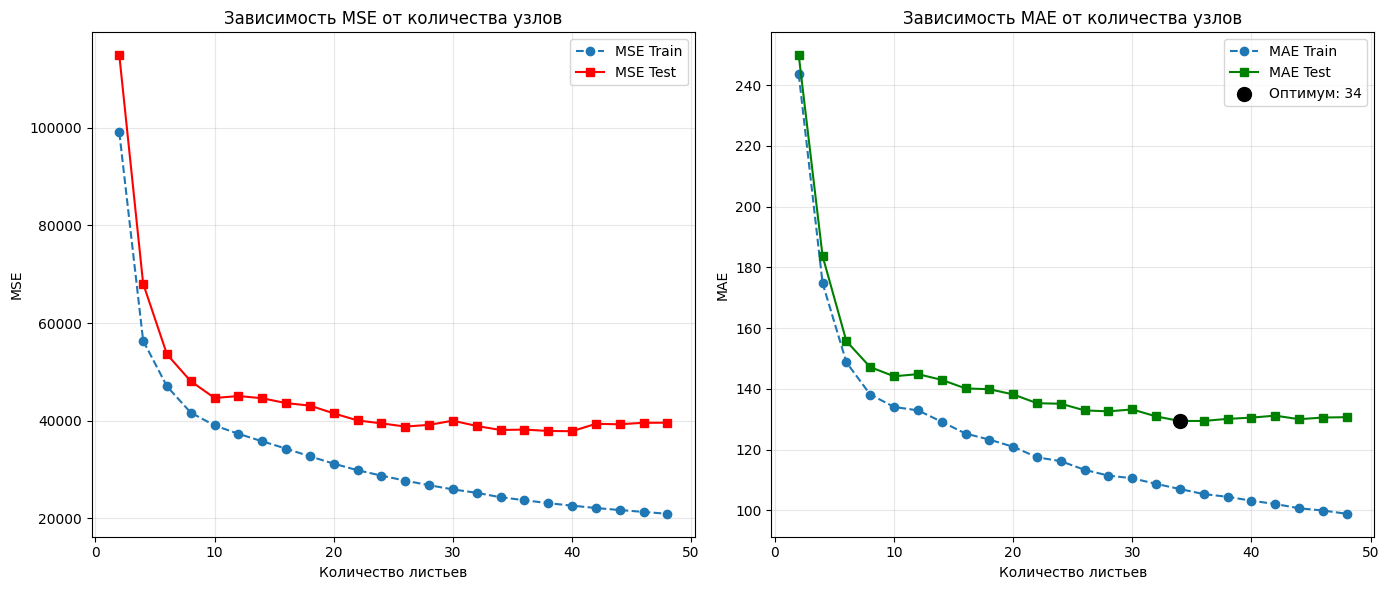

--- Оптимальные параметры по MAE ---
Оптимальное количество листьев: 34
Минимальная ошибка на тесте (MAE): 129.3905
Параметры сохраненной модели: max_leaf_nodes=34
MAE при повторном прогоне best_model: 129.3905 (должно совпадать с 129.3905)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Инициализация списков для хранения метрик
train_mse = []
test_mse = []
train_mae = []
test_mae = []

# Диапазон количества листьев: от 2 до 50 с шагом 2
max_leaf_nodes_range = range(2, 50, 2) 


best_model = None
best_nodes_mae = None
best_val_mae = float('inf')

# Цикл подбора параметра
for n_nodes in max_leaf_nodes_range:
    model = tree.DecisionTreeRegressor(max_leaf_nodes=n_nodes, random_state=42)
    

    model.fit(X_train, y_train)
    

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
 
    t_mse = mean_squared_error(y_train, train_pred)
    te_mse = mean_squared_error(y_test, test_pred)
    
   
    t_mae = mean_absolute_error(y_train, train_pred)
    te_mae = mean_absolute_error(y_test, test_pred)
    

    train_mse.append(t_mse)
    test_mse.append(te_mse)
    train_mae.append(t_mae)
    test_mae.append(te_mae)
    
   
    if te_mae < best_val_mae:
        best_val_mae = te_mae
        best_nodes_mae = n_nodes
        best_model = model  



plt.figure(figsize=(14, 6))

# График 1: MSE
plt.subplot(1, 2, 1)
plt.plot(max_leaf_nodes_range, train_mse, label='MSE Train', marker='o', linestyle='--')
plt.plot(max_leaf_nodes_range, test_mse, label='MSE Test', marker='s', color='red')
plt.xlabel('Количество листьев')
plt.ylabel('MSE')
plt.title('Зависимость MSE от количества узлов')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: MAE
plt.subplot(1, 2, 2)
plt.plot(max_leaf_nodes_range, train_mae, label='MAE Train', marker='o', linestyle='--')
plt.plot(max_leaf_nodes_range, test_mae, label='MAE Test', marker='s', color='green')


best_index = list(max_leaf_nodes_range).index(best_nodes_mae)
plt.scatter([best_nodes_mae], [test_mae[best_index]], color='black', s=100, zorder=5, label=f'Оптимум: {best_nodes_mae}')

plt.xlabel('Количество листьев')
plt.ylabel('MAE')
plt.title('Зависимость MAE от количества узлов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"--- Оптимальные параметры по MAE ---")
print(f"Оптимальное количество листьев: {best_nodes_mae}")
print(f"Минимальная ошибка на тесте (MAE): {best_val_mae:.4f}")


print(f"Параметры сохраненной модели: max_leaf_nodes={best_model.max_leaf_nodes}")

check_pred = best_model.predict(X_test)
check_mae = mean_absolute_error(y_test, check_pred)
print(f"MAE при повторном прогоне best_model: {check_mae:.4f} (должно совпадать с {best_val_mae:.4f})")
